<a href="https://colab.research.google.com/github/errodd/premier_league_football_predictor/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/errodd/premier_league_football_predictor/blob/main/notebooks/logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnolog%C3%ADa.svg.png?raw=1"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Exploratory Data Analysis: Titanic

## Purpose

This notebook presents a teaching example of **exploratory data analysis (EDA)**. Its goal is to understand the dataset's structure, quality, and patterns before building a model to predict passenger survival.

EDA is not intended to prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** Un partido de futbol de la liga inglesa  
**Target variable:** `FTR` Full Time Result (`H`=Home Win, `D`=Draw, `A`=Away Win)  
**Downstream problem type:** Clasificacion Multiclase.


## Guiding questions

1. Which variables and data types does the dataset contain?
2. Are there duplicates, missing values, or suspicious values?
3. How is the target variable distributed?
4. How is survival associated with sex, class, age, fare, and family structure?
5. Are there relevant interactions between variables?
6. What useful information can be extracted from `Name` and `Cabin`?
7. Which preprocessing hypotheses should be validated during modeling?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


In [90]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Allow execution from either the project root or the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)
if not (PROJECT_ROOT  / "data" / "processed" / "premier_league_2021_2026.csv" ).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "premier_league_2021_2026.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\Benja\Documents\machine learning\premier_league_football_predictor\notebooks


In [91]:
premier_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {premier_df.shape[0]} rows × {premier_df.shape[1]} columns")
premier_df.head()


Dimensions: 1900 rows × 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,BVH,BVD,BVA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,BVCH,BVCD,BVCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,8,22,3,4,12,8,2,5,0,0,0,0,4.000,3.400,1.950,4.000,3.500,1.950,3.800,3.400,2.050,4.050,3.460,2.050,4.000,3.400,1.900,4.100,3.400,2.000,4.620,3.720,2.100,4.020,3.430,2.020,2.100,1.720,2.220,1.730,2.260,1.830,2.160,1.730,0.500,1.860,2.070,1.880,2.060,2.050,2.080,1.870,2.030,3.800,3.250,2.050,3.800,3.300,2.050,3.800,3.250,2.100,3.940,3.330,2.130,3.900,3.000,2.050,3.900,3.250,2.100,4.200,3.500,2.180,3.890,3.280,2.100,2.370,1.570,2.440,1.620,2.470,1.750,2.330,1.620,0.500,1.750,2.050,1.810,2.130,2.050,2.170,1.800,2.090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,H,P Tierney,16,10,8,3,11,9,5,4,1,2,0,0,1.530,4.500,5.750,1.530,4.500,5.750,1.550,4.400,5.750,1.560,4.570,5.960,1.520,4.330,5.800,1.550,4.400,6.000,1.590,4.650,6.350,1.550,4.480,5.870,1.610,2.300,1.670,2.320,1.710,2.380,1.650,2.290,-1.000,1.950,1.980,1.960,1.960,2.000,2.010,1.930,1.960,1.610,4.200,5.250,1.620,4.100,5.250,1.650,4.200,4.900,1.670,4.200,5.400,1.570,4.200,5.500,1.650,4.100,5.250,1.710,4.330,5.800,1.640,4.190,5.220,1.660,2.200,1.700,2.270,1.750,2.370,1.670,2.250,-1.000,2.050,1.750,2.170,1.770,2.190,1.930,2.100,1.790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,H,D Coote,14,14,3,8,10,7,7,6,2,1,0,0,3.100,3.100,2.450,3.200,3.100,2.400,3.150,3.050,2.450,3.300,3.120,2.510,3.200,3.000,2.450,3.130,3.100,2.450,3.330,3.200,2.600,3.190,3.090,2.490,2.500,1.530,2.560,1.560,2.560,1.630,2.460,1.570,0.250,1.800,2.140,1.830,2.120,1.830,2.170,1.790,2.120,3.100,3.100,2.450,3.250,3.100,2.400,3.100,3.050,2.450,3.270,3.140,2.510,3.100,3.000,2.450,3.130,3.130,2.500,3.350,3.200,2.560,3.190,3.100,2.480,2.300,1.610,2.330,1.670,2.420,1.710,2.340,1.620,0.250,1.790,2.150,1.810,2.140,1.820,2.190,1.790,2.120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,13,4,6,1,15,11,5,2,0,0,0,0,1.250,5.750,13.000,1.280,5.750,10.500,1.250,6.000,13.000,1.260,6.240,12.740,1.250,5.500,13.000,1.250,5.750,13.000,1.300,6.300,15.000,1.260,5.920,12.800,1.800,2.000,1.800,2.090,1.840,2.120,1.790,2.060,-1.500,1.840,2.090,1.790,2.120,1.930,2.120,1.830,2.070,1.300,5.250,11.000,1.330,5.000,10.000,1.300,5.250,11.000,1.340,5.400,11.000,1.300,5.250,10.000,1.330,5.000,11.000,1.360,5.500,11.500,1.330,5.170,10.580,1.900,1.900,1.930,1.980,1.960,2.070,1.900,1.940,-1.500,2.050,1.750,2.120,1.810,2.160,1.930,2.060,1.820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

# 1. Data understanding and quality

We begin by examining the dataset's structure. The data types stored by pandas do not always match each variable's analytical role:

- `Season` es un identificador de la temporada de donde son los datos se guardan como strings.
- `Div` nos dice la division de la liga y tambien se guarda como strings
- `Date` and `Time` Son variables de tipo string para representar la fecha y hora.
- `HomeTeam` y `AwayTeam` Contienen textos que representan a los equipos.
- `FTR` and `HTR` Son los resultados de tanto del partido completo y de medio tiempo respectivamente, este es categorico entre (H=Home,A=Away,D=Draw)
- `Name`, `Ticket`, and `Cabin` contain text from which useful information might be extracted.


In [92]:
premier_df.info( verbose=True, show_counts=True )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 157 columns):
 #    Column     Non-Null Count  Dtype  
---   ------     --------------  -----  
 0    Season     1900 non-null   object 
 1    Div        1900 non-null   object 
 2    Date       1900 non-null   object 
 3    Time       1900 non-null   object 
 4    HomeTeam   1900 non-null   object 
 5    AwayTeam   1900 non-null   object 
 6    FTHG       1900 non-null   int64  
 7    FTAG       1900 non-null   int64  
 8    FTR        1900 non-null   object 
 9    HTHG       1900 non-null   int64  
 10   HTAG       1900 non-null   int64  
 11   HTR        1900 non-null   object 
 12   Referee    1900 non-null   object 
 13   HS         1900 non-null   int64  
 14   AS         1900 non-null   int64  
 15   HST        1900 non-null   int64  
 16   AST        1900 non-null   int64  
 17   HF         1900 non-null   int64  
 18   AF         1900 non-null   int64  
 19   HC         1900 non-null 

In [93]:
quality_summary = pd.DataFrame({
    "dtype": premier_df.dtypes.astype(str),
    "missing_n": premier_df.isna().sum(),
    "missing_pct": premier_df.isna().mean().mul(100),
    "unique_n": premier_df.nunique(dropna=True),
})
quality_summary.sort_values("missing_pct", ascending=False )


,dtype,missing_n,missing_pct,unique_n
CLCH,float64,1640,86.316,73
CLCA,float64,1640,86.316,68
CLCD,float64,1640,86.316,30
LBCH,float64,1619,85.211,74
LBCD,float64,1619,85.211,30
LBCA,float64,1619,85.211,71
CLD,float64,1618,85.158,29
CLH,float64,1618,85.158,75
CLA,float64,1618,85.158,74
LBH,float64,1614,84.947,76


In [94]:
checks = pd.Series({
    "duplicated_rows": premier_df.duplicated().sum(),
    "negative_goals_home": premier_df["FTHG"].lt(0).sum(),
    "negative_goals_away": premier_df["FTAG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTHG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTAG"].lt(0).sum(),
    "draw_match": ( premier_df[ "FTR" ] == "D" ).sum(),
    "home_win_match": ( premier_df[ "FTR" ] == "H" ).sum(),
    "away_win_match": ( premier_df[ "FTR" ] == "A" ).sum(),
    "yellow_card_negative_home": premier_df[ "HY" ].lt(0).sum(),
    "yellow_card_negative_away": premier_df[ "AY" ].lt(0).sum(),
    "negative_shots_home": premier_df["HS"].lt(0).sum(),
    "negative_shots_away": premier_df["AS"].lt(0).sum(),
    "negative_shots_at_target_home": premier_df["HST"].lt(0).sum(),
    "negative_shots_at_target_away": premier_df["AST"].lt(0).sum(),
    "negative_fouls_home": premier_df["HF"].lt(0).sum(),
    "negative_fouls_away": premier_df["AF"].lt(0).sum(),
    "negative_corners_home": premier_df["HC"].lt(0).sum(),
    "negative_corners_away": premier_df["AC"].lt(0).sum(),
    "Referee_null_name":premier_df["Referee"].isna().sum(),
    "ht_goals_gt_ft_home": (premier_df["HTHG"] > premier_df["FTHG"]).sum(),
    "ht_goals_gt_ft_away": (premier_df["HTAG"] > premier_df["FTAG"]).sum(),
    "false_draw": ((premier_df["FTHG"] != premier_df["FTAG"]) & (premier_df["FTR"] == "D")).sum(),
    "false_home_win": ((premier_df["FTHG"] <= premier_df["FTAG"]) & (premier_df["FTR"] == "H")).sum(),
    "false_away_win": ((premier_df["FTAG"] <= premier_df["FTHG"]) & (premier_df["FTR"] == "A")).sum(),
    "impossible_shots_target_home": (premier_df["HST"] > premier_df["HS"]).sum(),
    "impossible_shots_target_away": (premier_df["AST"] > premier_df["AS"]).sum(),
    "excessive_red_cards_home": (premier_df["HR"] > 5).sum(),
    "excessive_red_cards_away": (premier_df["AR"] > 5).sum(),
})
checks.to_frame("count")


,count
duplicated_rows,0
negative_goals_home,0
negative_goals_away,0
negative_goals_home_half_time,0
draw_match,454
home_win_match,839
away_win_match,607
yellow_card_negative_home,0
yellow_card_negative_away,0
negative_shots_home,0


In [95]:
error_tiros = premier_df[premier_df["AST"] > premier_df["AS"]]

# Imprimimos las columnas clave para identificar el partido fácilmente
columnas_ver = ["Date", "HomeTeam", "AwayTeam", "AS", "AST"]
print(error_tiros[columnas_ver])


         Date   HomeTeam  AwayTeam  AS  AST
8  15/08/2021  Newcastle  West Ham   8    9


colocar que son 18 y no 8

### Data quality observations

- `Cabin` and `Age` contain most of the missing values; `Embarked` has only two.
- `PassengerId` is unique and has no direct predictive meaning.
- There are no fully duplicated rows, negative ages, or negative fares.
- Some fares are equal to zero. These are not necessarily errors: they may represent group tickets, complimentary travel, or incomplete records. They should be investigated rather than automatically removed.
- `Name` and `Ticket` have high cardinality. This does not mean that they contain no information, but using them directly without transformation may not be appropriate.


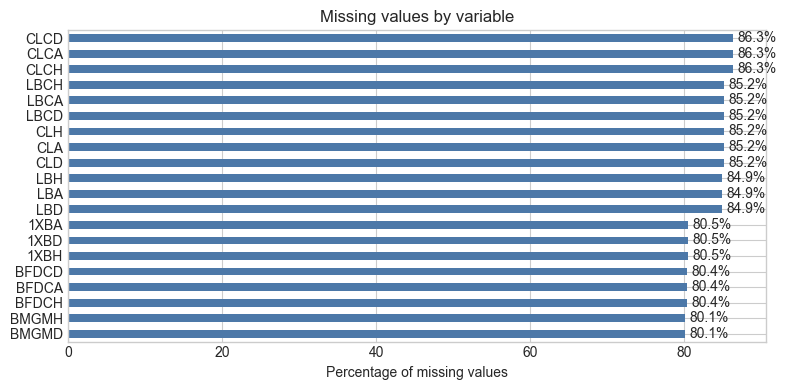

In [96]:
missing_pct = premier_df.isna().mean().mul(100).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set(title="Missing values by variable", xlabel="Percentage of missing values", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


The high missingness rate in `Cabin` discourages using its complete text directly. However, we can still explore whether cabin availability or deck contains useful information. A high missingness rate alone does not justify dropping a variable.


# 2. Target variable

In addition to examining class proportions, we calculate a **baseline**: a classifier that always predicts the majority class would achieve approximately 61.6% accuracy. During modeling, accuracy should therefore be compared with this reference and complemented with metrics such as recall, F1, or ROC-AUC, depending on the objective.


In [97]:
target_summary = (
    premier_df["FTR"]
    .value_counts()
    .rename( index = { 0: "Home", 1: "Away", 2: "Draw"} )
    .to_frame("n")
)
target_summary["pct"] = target_summary["n"].div(len(premier_df)).mul(100)
target_summary


,n,pct
FTR,,
H,839,44.158
A,607,31.947
D,454,23.895


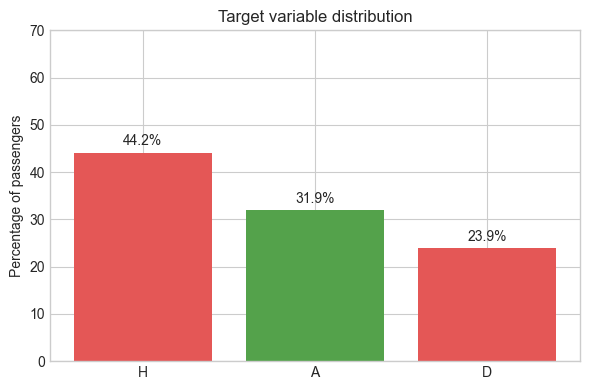

In [98]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_summary.index, target_summary["pct"], color=["#E45756", "#54A24B"])
ax.set(title="Target variable distribution", ylabel="Percentage of passengers", ylim=(0, 70))
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


# 3. Categorical variables and survival

To avoid misleading interpretations, the following tables report the group size (`n`), number of survivors, and survival rate together.


In [99]:

def match_outcomes_summary(data, group_cols, target_col):
    """
    Resume la cantidad de partidos y el desglose de resultados (H, D, A) 
    para cualquier agrupación de variables.
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    
    # 1. Agrupamos y contamos las frecuencias de cada clase (H, D, A)
    summary = (
        data.groupby(group_cols, observed=True)[target_col]
        .value_counts()
        .unstack(fill_value=0) # Convierte las filas de clases en columnas
    )
    
    # 2. Calculamos el total de partidos para ese grupo
    summary["Total"] = summary.sum(axis=1)
    
    # 3. Calculamos los porcentajes dinámicamente para cada clase existente
    # Usamos las clases reales encontradas en la tabla pivote
    classes = [col for col in summary.columns if col != "Total"]
    
    for col in classes:
        summary[f"{col}_pct"] = (summary[col] / summary["Total"] * 100).round(2)
        
    return summary

# --- APLICACIÓN ---

# Desglose del resultado final (FTR) por Temporada
season_ftr_summary = match_outcomes_summary(premier_df, "Season", "FTR")

# Desglose del resultado al medio tiempo (HTR) por Temporada
season_htr_summary = match_outcomes_summary(premier_df, "HTR", "FTR")

referee_summary = match_outcomes_summary(premier_df, "Referee", "FTR")

nombre_casa = match_outcomes_summary(premier_df, "HomeTeam", "FTR")
nombre_visitante = match_outcomes_summary(premier_df, "AwayTeam", "FTR")
division_completo = match_outcomes_summary(premier_df, "Div", "FTR")


display(season_ftr_summary)
display(season_htr_summary)
display(referee_summary)
display(nombre_casa)
display(nombre_visitante)
display(division_completo)

FTR,A,D,H,Total,A_pct,D_pct,H_pct
Season,,,,,,,
2021-2022,129,88,163,380,33.950,23.160,42.890
2022-2023,109,87,184,380,28.680,22.890,48.420
2023-2024,123,82,175,380,32.370,21.580,46.050
2024-2025,132,93,155,380,34.740,24.470,40.790
2025-2026,114,104,162,380,30.000,27.370,42.630


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HTR,,,,,,,
A,343,87,60,490,70.000,17.760,12.240
D,210,253,266,729,28.810,34.710,36.490
H,54,114,513,681,7.930,16.740,75.330


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Kitchen,0,3,3,6,0.000,50.000,50.000
A Madley,35,23,46,104,33.650,22.120,44.230
A Marriner,16,6,10,32,50.000,18.750,31.250
A Taylor,54,39,53,146,36.990,26.710,36.300
C Kavanagh,36,28,41,105,34.290,26.670,39.050
C Pawson,40,25,44,109,36.700,22.940,40.370
D Bond,5,6,12,23,21.740,26.090,52.170
D Coote,21,16,26,63,33.330,25.400,41.270
D England,25,23,39,87,28.740,26.440,44.830


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HomeTeam,,,,,,,
Arsenal,12,15,68,95,12.630,15.790,71.580
Aston Villa,22,20,53,95,23.160,21.050,55.790
Bournemouth,24,24,28,76,31.580,31.580,36.840
Brentford,27,29,39,95,28.420,30.530,41.050
Brighton,24,31,40,95,25.260,32.630,42.110
Burnley,31,17,9,57,54.390,29.820,15.790
Chelsea,22,28,45,95,23.160,29.470,47.370
Crystal Palace,28,35,32,95,29.470,36.840,33.680
Everton,38,23,34,95,40.000,24.210,35.790


FTR,A,D,H,Total,A_pct,D_pct,H_pct
AwayTeam,,,,,,,
Arsenal,54,20,21,95,56.840,21.050,22.110
Aston Villa,36,18,41,95,37.890,18.950,43.160
Bournemouth,24,20,32,76,31.580,26.320,42.110
Brentford,29,20,46,95,30.530,21.050,48.420
Brighton,32,28,35,95,33.680,29.470,36.840
Burnley,7,16,34,57,12.280,28.070,59.650
Chelsea,39,22,34,95,41.050,23.160,35.790
Crystal Palace,27,28,40,95,28.420,29.470,42.110
Everton,22,29,44,95,23.160,30.530,46.320


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Div,,,,,,,
E0,607,454,839,1900,31.950,23.890,44.160


In [100]:
columnas_pct = ["H_pct", "D_pct", "A_pct"]
colores = ["#2CA02C", "#7F7F7F", "#D62728"] # Verde (H), Gris (D), Rojo (A)
leyenda_nombres = ["Home Win (H)", "Draw (D)", "Away Win (A)"]

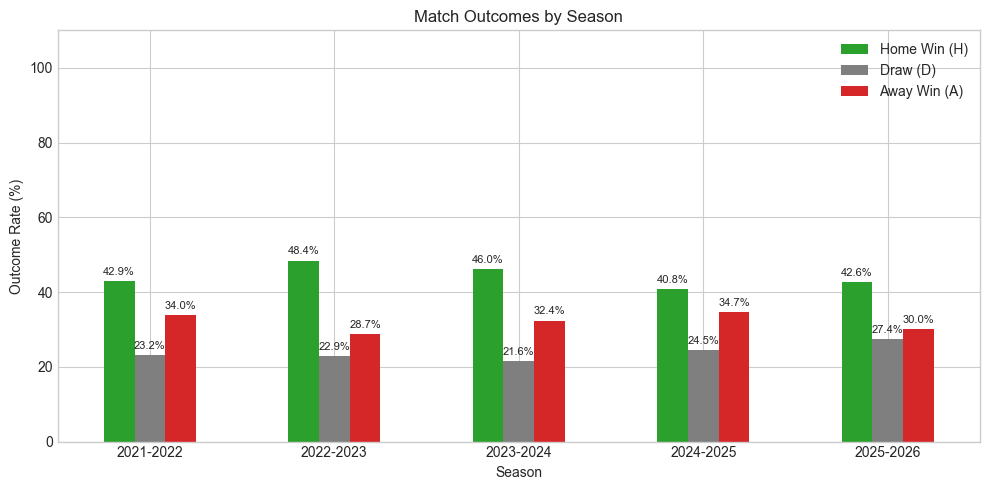

In [101]:
fig, ax = plt.subplots(figsize=(10, 5))

season_ftr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Match Outcomes by Season", xlabel="Season", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

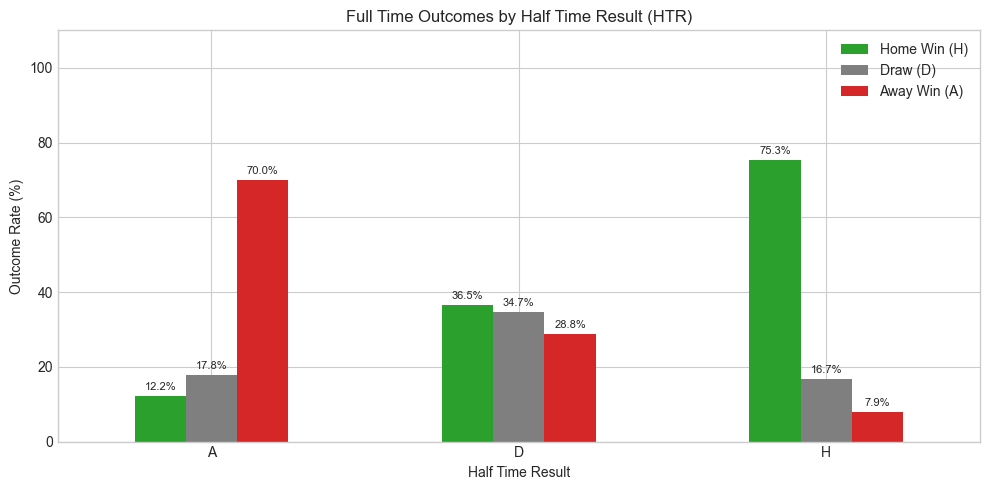

In [102]:
fig, ax = plt.subplots(figsize=(10, 5))

season_htr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Full Time Outcomes by Half Time Result (HTR)", xlabel="Half Time Result", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

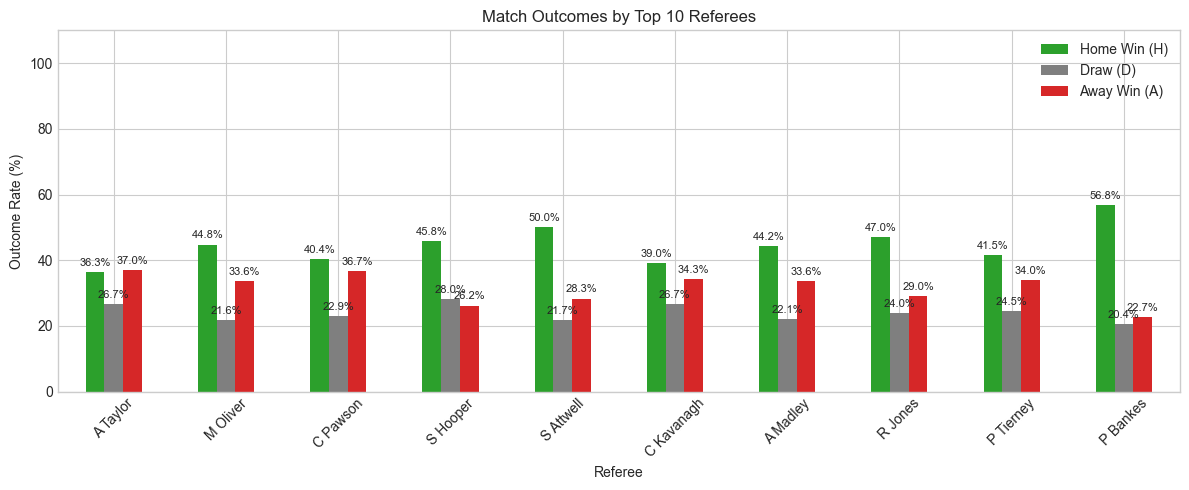

In [103]:
fig, ax = plt.subplots(figsize=(12, 5))

# Filtramos el top 10
top_referees = referee_summary.sort_values("Total", ascending=False).head(10)

top_referees[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=45)
ax.set(title="Match Outcomes by Top 10 Referees", xlabel="Referee", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

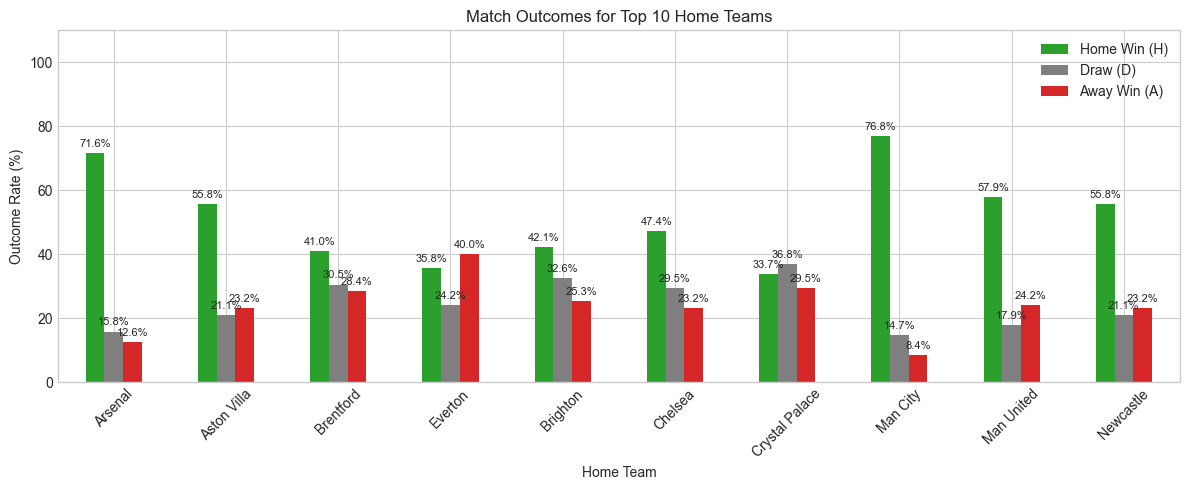

In [104]:
fig, ax = plt.subplots(figsize=(12, 5))

# Filtramos los 10 equipos que más han jugado de local
top_home_teams = nombre_casa.sort_values("Total", ascending=False).head(10)

top_home_teams[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=45)
ax.set(title="Match Outcomes for Top 10 Home Teams", xlabel="Home Team", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

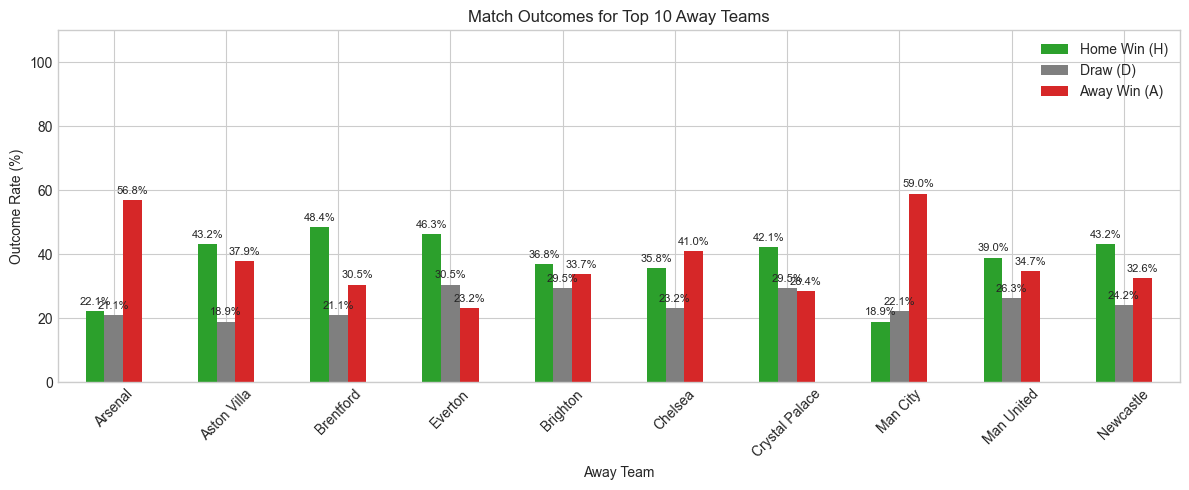

In [105]:
fig, ax = plt.subplots(figsize=(12, 5))

# Filtramos los 10 equipos que más han jugado de visitante
top_away_teams = nombre_visitante.sort_values("Total", ascending=False).head(10)

top_away_teams[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=45)
ax.set(title="Match Outcomes for Top 10 Away Teams", xlabel="Away Team", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Findings

- In this sample, women have a much higher survival rate than men.
- Survival decreases from first to third class.
- These are strong and potentially predictive associations, but they do not prove that either variable alone caused the outcome.
- Although `Pclass` is conceptually ordered, linear models should compare ordinal and one-hot encoding. Using 1, 2, and 3 as numbers imposes a linear effect that may not be appropriate.


In [111]:
home_team_season_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "Season" ], "FTR")
#display(home_team_season_summary)
away_team_season_summary = match_outcomes_summary( premier_df, [ "AwayTeam", "Season" ], "FTR")
#display(away_team_season_summary)
home_away_team_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "AwayTeam" ], "FTR")
#display(home_away_team_summary)


In [ ]:
interaction_plot = sex_class_summary["survival_pct"].unstack("Sex")

ax = interaction_plot.plot(kind="bar", figsize=(8, 4), rot=0, color=["#ECA82C", "#4C78A8"])
ax.set(title="Interaction between sex and class", xlabel="Passenger class", ylabel="Survival rate (%)", ylim=(0, 105))
ax.legend(title="Sex")
plt.tight_layout()
plt.show()


The observed survival advantage for women is not equal across classes: women in third class have a much lower survival rate than women in first and second class. This suggests a `Sex × Pclass` interaction. Tree-based models may capture it naturally; a linear model would need to evaluate it explicitly.


# 4. Age: distribution, missingness, and relationship with survival

Before grouping a continuous variable, we examine its distribution. Age intervals facilitate communication, but their boundaries are analytical choices and may hide variation within each group.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

titanic_df["Age"].plot(kind="hist", bins=25, ax=axes[0], color="#4C78A8", edgecolor="white")
axes[0].set(title="Age distribution", xlabel="Age", ylabel="Count")

for survived, label, color in [(0, "Did not survive", "#E45756"), (1, "Survived", "#54A24B")]:
    ages = titanic_df.loc[titanic_df["Survived"].eq(survived), "Age"].dropna()
    axes[1].hist(ages, bins=20, density=True, alpha=0.45, label=label, color=color)
axes[1].set(title="Age by survival", xlabel="Age", ylabel="Relative density", xlim=(0, 85))
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
age_labels = ["Childhood (0–12]", "Adolescence (12–18]", "Young adult (18–35]", "Adult (35–60]", "Older adult (60–100]"]
titanic_df["age_group"] = pd.cut(
    titanic_df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=age_labels,
)

age_summary = survival_summary(titanic_df, "age_group")
age_summary


In [ ]:
age_sex_summary = survival_summary(titanic_df, ["age_group", "Sex"])
age_sex_summary


### Interpret with caution

- The association between age and survival does not appear fully linear.
- During childhood, survival rates are similar for girls and boys; a large difference by sex appears from adolescence onward.
- The group older than 60 contains only 22 passengers with recorded ages and just 3 women. Its 100% female survival rate should not be generalized because it is based on an extremely small sample.
- Age may interact with sex, class, and title. These hypotheses must be validated beyond the EDA.


In [ ]:
age_missing_by_class = pd.crosstab(
    titanic_df["Pclass"], titanic_df["Age"].isna(), normalize="index"
).rename(columns={False: "Age available", True: "Age missing"}).mul(100)

age_missing_by_sex = pd.crosstab(
    titanic_df["Sex"], titanic_df["Age"].isna(), normalize="index"
).rename(columns={False: "Age available", True: "Age missing"}).mul(100)

display(age_missing_by_class)
display(age_missing_by_sex)


Missingness in `Age` varies by class and sex, especially by `Pclass`. This provides evidence that the missingness is not completely random (MCAR), but it does not by itself distinguish between MAR and MNAR.

Global mean imputation would ignore this structure. During modeling, we can compare strategies based on medians by class/title or multivariate imputers. **The imputer must be fitted using the training set only** to prevent data leakage.


# 5. Family structure

`SibSp` and `Parch` support two feature hypotheses: family group size and traveling alone. These derived variables should not automatically replace the original variables; their comparative value should be determined through validation.


In [ ]:
titanic_df["family_size"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df["is_alone"] = titanic_df["family_size"].eq(1).astype(int)

family_summary = survival_summary(titanic_df, "family_size")
family_summary


In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(family_summary.index, family_summary["survival_pct"], marker="o", color="#4C78A8")
ax1.set(title="Family size, survival, and sample size", xlabel="Family size", ylabel="Survival rate (%)", ylim=(0, 100))

ax2 = ax1.twinx()
ax2.bar(family_summary.index, family_summary["n"], alpha=0.18, color="#4C78A8")
ax2.set_ylabel("Number of passengers")

plt.tight_layout()
plt.show()


Passengers traveling alone have a lower survival rate than those traveling in small families. Very large families also have low rates, but some sizes contain very few observations: family sizes 8 and 11 contain only 6 and 7 passengers. This is a **nonlinear association**, not evidence of a causal “protective effect.”


# 6. Fare and passenger class

`Fare` is positively skewed and contains extreme values. It is also related to `Pclass`, although it may provide additional variation within each class.


In [ ]:
titanic_df["Fare"].describe().to_frame().T


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

titanic_df["Fare"].hist(bins=30, ax=axes[0], color="#4C78A8")
axes[0].set(title="Original fare", xlabel="Fare", ylabel="Count")

np.log1p(titanic_df["Fare"]).hist(bins=30, ax=axes[1], color="#72B7B2")
axes[1].set(title="log(1 + Fare)", xlabel="Transformed fare", ylabel="Count")

titanic_df.boxplot(column="Fare", by="Pclass", ax=axes[2], grid=False)
axes[2].set(title="Fare by passenger class", xlabel="Passenger class", ylabel="Fare")
plt.suptitle("")

plt.tight_layout()
plt.show()


The `log1p` transformation visually reduces skewness, but it is not universally required. It often benefits models that are sensitive to scale or linearity and may be unnecessary for some tree-based models. Extreme values and the 15 zero fares should be retained until their origin is understood.


# 7. Information derived from name and cabin

High cardinality does not automatically require dropping a column. We can extract a title from `Name`; when `Cabin` is available, we can extract the deck and an availability indicator. We must then examine group sizes and redundancy with other variables.


In [ ]:
titanic_df["title"] = titanic_df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

rare_titles = titanic_df["title"].value_counts().loc[lambda s: s < 10].index
titanic_df["title_grouped"] = titanic_df["title"].replace(rare_titles, "Rare")

title_summary = survival_summary(titanic_df, "title_grouped").sort_values("n", ascending=False)
title_summary


In [ ]:
titanic_df["has_cabin"] = titanic_df["Cabin"].notna().astype(int)
titanic_df["deck"] = titanic_df["Cabin"].str[0].fillna("Unknown")

display(survival_summary(titanic_df, "has_cabin"))
display(survival_summary(titanic_df, "deck").sort_values("n", ascending=False))
display(pd.crosstab(titanic_df["Pclass"], titanic_df["has_cabin"], normalize="index").mul(100))


### Interpretation

- Title summarizes information related to sex, age, and social status. It may be useful, but also redundant. Rare titles are grouped to avoid extremely small categories.
- Having a recorded cabin is associated with survival, but it is also strongly associated with class. `has_cabin` may mainly act as a proxy for status or record quality.
- Several decks contain very few passengers and should not be interpreted individually without grouping them or regularizing the model.
- The true value of these features must be evaluated with cross-validation, not solely from rates observed across the full dataset.


# 8. Conclusions and roadmap

## Descriptive findings

1. `Sex` and `Pclass` show strong associations with survival.
2. There is an important interaction between these variables.
3. The relationship with `Age` appears nonlinear and conditional on sex; its missingness is also structured.
4. Family size shows a nonlinear pattern, although large groups have small sample sizes.
5. `Fare` is skewed, contains extreme values, and is related to class.
6. `title`, `has_cabin`, and `deck` summarize potentially useful but also redundant information.

## Hypotheses to validate during modeling

| Variable | Candidate strategy | Caution |
|---|---|---|
| `PassengerId` | Exclude | It is an identifier |
| `Sex`, `Embarked` | Categorical encoding | Fit the encoder on training data only |
| `Pclass` | Compare ordinal vs. one-hot | Do not impose linearity without validation |
| `Age` | Missingness indicator + conditional imputation | Fit the imputer on training data only |
| `Fare` | Compare original vs. `log1p` | Investigate zero and extreme values |
| `SibSp`, `Parch` | Compare with `family_size` and `is_alone` | Do not drop the originals prematurely |
| `Name` | Use grouped title | Control redundancy and rare categories |
| `Cabin` | Test `has_cabin` and grouped deck | High missingness and confounding with class |
| `Ticket` | Explore group size/prefix or exclude | High cardinality |

## Limitations

- The dataset is small and several subgroups contain few observations.
- Associations do not demonstrate causality.
- Age intervals and rare-category thresholds are adjustable analytical decisions.
- Any learned transformation, imputation, or feature selection must be performed inside the pipeline using training data only.

The next step is not to assume that these decisions are correct, but to compare them using cross-validation and appropriate metrics.
